# Model explorer

Look at what a trained model predicts on images it has never trained on, next to what the scientists drew.

- **Validation images** (106 files) were held out from training and come with the annotators' masks, so you can compare and get a score.
- **Test images** (180 files) have no annotations. You can only see what the model predicts.

Run all cells, then use the controls in **section 4**. The first prediction on an image takes a few seconds (the model runs on your GPU
or CPU); after that it is cached, so moving the cutoff slider is instant.

**Colours.** Annotators: each filament gets its own colour (colours are not matched between annotators).
Model: **green** = would count as a match for at least one annotator (IoU > 0.5), **red** = no match. On test images there is no ground truth, so the model is drawn in orange.

## 1. Settings

In [1]:
from pathlib import Path

PROJECT_ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()

# Models you can pick from: name -> (config file, checkpoint). Add your own here.
ALL_MODELS = {
    # run 1 (V1/): raw and limb-corrected images
    "V1 raw, final epoch":                 ("V1/configs/maskrcnn_baseline.yaml", "V1/checkpoints/raw/last.pt"),
    "V1 limb-corrected, final epoch":      ("V1/configs/maskrcnn_limb.yaml",     "V1/checkpoints/limb/last.pt"),
    "V1 raw, lowest val loss":             ("V1/configs/maskrcnn_baseline.yaml", "V1/checkpoints/raw/best.pt"),
    "V1 limb-corrected, lowest val loss":  ("V1/configs/maskrcnn_limb.yaml",     "V1/checkpoints/limb/best.pt"),
    # run 2 (V2/): appear here once they exist
    "V2 run1, best PQ":                    ("V2/configs/maskrcnn_v2.yaml",       "V2/checkpoints/run1/best_pq.pt"),
    "V2 run1, final epoch":                ("V2/configs/maskrcnn_v2.yaml",       "V2/checkpoints/run1/last.pt"),
}
MODELS = {name: v for name, v in ALL_MODELS.items() if (PROJECT_ROOT / v[1]).exists()}    # only checkpoints that exist
DEFAULT_MODEL = "V1 raw, final epoch"
DEFAULT_CUTOFF = 0.8          # keep a predicted filament only if its score is at least this

# Section 5 (rank validation images by score)
RANK_MODEL = "V1 raw, final epoch"
RANK_N_IMAGES = 30            # how many validation images to score (all 106 takes a few minutes)
RANK_CUTOFF = 0.8

## 2. Setup

In [2]:
import json
import os
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import yaml
from PIL import Image
from pycocotools import mask as mask_util
from scipy import ndimage as ndi

ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
os.chdir(ROOT)                                   # the project's config files use paths relative to the project root
sys.path.insert(0, str(ROOT / "scripts"))

from dataset import load_image_tensor, read_split
from metrics import get_overlap_df, pq_breakdown, polygon_to_rle
from model import get_device
from predict import load_model, predict_instances

base_cfg = yaml.safe_load(open("V2/configs/maskrcnn_v2.yaml"))
RAW_TRAIN_DIR = Path(base_cfg["data"]["train_images"])
RAW_TEST_DIR = Path(base_cfg["data"]["test_images"])

coco = json.load(open(base_cfg["data"]["annotations"]))
file_of = {im["id"]: im["file_name"] for im in coco["images"]}
size_of = {im["id"]: (im["height"], im["width"]) for im in coco["images"]}
anns = {}
for a in coco["annotations"]:
    anns.setdefault(a["image_id"], []).append(a)

val_by_file = {}
for i in read_split(base_cfg["data"]["val_split"]):
    val_by_file.setdefault(file_of[i], []).append(i)
VAL_FILES = sorted(val_by_file)
TEST_FILES = sorted(f.name for f in RAW_TEST_DIR.glob("*") if f.suffix.lower() in (".jpeg", ".jpg", ".png"))
SOURCES = {"validation (has ground truth)": VAL_FILES, "test (no ground truth)": TEST_FILES}

device = get_device()
missing = [n for n, (c, p) in MODELS.items() if not Path(p).exists()]
print(f"device: {device} | {len(VAL_FILES)} validation images, {len(TEST_FILES)} test images")
print("missing checkpoints:", missing or "none")

device: mps | 106 validation images, 180 test images
missing checkpoints: none


## 3. Prediction and scoring helpers

Nothing to edit here. Models are loaded once, and every prediction is cached.

In [3]:
_models, _pred_cache = {}, {}
ANN_COLORS = [(230, 25, 75), (60, 180, 75), (255, 225, 25), (0, 130, 200), (245, 130, 48), (145, 30, 180),
              (70, 240, 240), (240, 50, 230), (210, 245, 60), (250, 190, 212), (0, 128, 128), (170, 110, 40)]
GREEN, RED, ORANGE = (60, 220, 90), (255, 60, 60), (255, 150, 30)


def get_model(name):
    if name not in _models:
        cfg_path, ckpt = MODELS[name]
        _models[name] = (load_model(yaml.safe_load(open(cfg_path)), ckpt, device), yaml.safe_load(open(cfg_path)))
    return _models[name]


def get_instances(name, source, file):
    """[(score, rle), ...] for one image, highest score first. Cached."""
    key = (name, source.split()[0], file)
    if key not in _pred_cache:
        model, cfg = get_model(name)
        image_dir = cfg["data"]["train_images"] if source.startswith("validation") else cfg["data"]["test_images"]
        image = load_image_tensor(image_dir, file)
        _pred_cache[key] = predict_instances(model, image, device, mask_threshold=cfg["predict"]["mask_threshold"])
    return _pred_cache[key]


def decode(rles, h=2048, w=2048):
    return [mask_util.decode({"size": [h, w], "counts": r.encode("ascii")}) for r in rles]


def gt_for(file):
    ids = sorted(val_by_file[file])
    h, w = size_of[ids[0]]
    return ids, {i: [polygon_to_rle(a["segmentation"], h, w) for a in anns.get(i, [])] for i in ids}


def score_image(file, pred_rles):
    """Official PQ of the predictions against each annotator, plus each prediction's best IoU with any annotator filament."""
    ids, gt = gt_for(file)
    cols = ["filament_id", "segmentation_rle"]
    stem = Path(file).stem
    pred_df = pd.DataFrame([(f"{stem}_{k}", r) for k, r in enumerate(pred_rles)], columns=cols)
    per_annotator = {}
    for i in ids:
        gt_df = pd.DataFrame([(f"{i}_{k}", r) for k, r in enumerate(gt[i])], columns=cols)
        per_annotator[i] = pq_breakdown(get_overlap_df(gt_df, pred_df))
    all_gt = [r for i in ids for r in gt[i]]
    as_rle = lambda rs: [{"size": [2048, 2048], "counts": r.encode("ascii")} for r in rs]
    if pred_rles and all_gt:
        best = mask_util.iou(as_rle(pred_rles), as_rle(all_gt), [0] * len(all_gt)).max(axis=1)
    else:
        best = np.zeros(len(pred_rles))
    return per_annotator, best


def stretched_raw(file, source):
    path = (RAW_TRAIN_DIR if source.startswith("validation") else RAW_TEST_DIR) / file
    g = np.asarray(Image.open(path).convert("L"), dtype=np.float32)
    lo, hi = np.percentile(g, [1, 99.5])
    return np.clip((g - lo) / max(hi - lo, 1e-6), 0, 1)


def overlay(masks, colors, crop, alpha=0.45):
    x0, y0, s = crop
    out = np.zeros((s, s, 4), np.float32)
    for m, c in zip(masks, colors):
        sub = m[y0:y0 + s, x0:x0 + s].astype(bool)
        out[sub, :3] = np.array(c) / 255
        out[sub, 3] = alpha
        out[sub & ~ndi.binary_erosion(sub), 3] = 1.0          # solid outline
    return out

## 4. The explorer

- **model / compare with**: pick a model, and optionally a second one to see side by side.
- **source / image**: validation images have annotations; test images do not.
- **cutoff**: minimum score for a predicted filament to be kept. Lower shows more (and more wrong) filaments.
- **x, y, size**: zoom into a region at full resolution (the full image is 2048 pixels wide).
- **random image**: jump to a random image from the current source.

In [4]:
import ipywidgets as W
from IPython.display import display

style = {"description_width": "90px"}
model_dd = W.Dropdown(options=list(MODELS), value=DEFAULT_MODEL, description="model", style=style)
compare_dd = W.Dropdown(options=["(none)"] + list(MODELS), value="(none)", description="compare with", style=style)
source_dd = W.Dropdown(options=list(SOURCES), value=list(SOURCES)[0], description="source", style=style)
image_dd = W.Dropdown(options=VAL_FILES, value=VAL_FILES[0], description="image", style=style,
                      layout=W.Layout(width="420px"))
cutoff_sl = W.FloatSlider(min=0.05, max=0.99, step=0.05, value=DEFAULT_CUTOFF, description="cutoff",
                          continuous_update=False, style=style)
show_gt = W.Checkbox(value=True, description="show annotators", indent=False)
x_sl = W.IntSlider(min=0, max=1800, step=50, value=0, description="x", continuous_update=False, style=style)
y_sl = W.IntSlider(min=0, max=1800, step=50, value=0, description="y", continuous_update=False, style=style)
size_sl = W.IntSlider(min=200, max=2048, step=100, value=2048, description="size (2048 = all)",
                      continuous_update=False, style=style)
random_btn = W.Button(description="random image")


def on_source(change):
    image_dd.options = SOURCES[source_dd.value]
    image_dd.value = image_dd.options[0]


def on_random(_):
    image_dd.value = np.random.choice(SOURCES[source_dd.value])


source_dd.observe(on_source, names="value")
random_btn.on_click(on_random)


def render(model, compare, source, file, cutoff, show_annotators, x, y, size):
    size = int(min(size, 2048))
    x, y = int(min(x, 2048 - size)), int(min(y, 2048 - size))
    crop = (x, y, size)
    has_gt = source.startswith("validation")
    raw = stretched_raw(file, source)
    panels = [("raw image", raw, None)]
    text = []

    if has_gt and show_annotators:
        ids, gt = gt_for(file)
        for i in ids:
            ms = decode(gt[i])
            panels.append((f"annotator {i.split('-')[0]}: {len(ms)} filaments", raw,
                           overlay(ms, [ANN_COLORS[k % len(ANN_COLORS)] for k in range(len(ms))], crop)))

    for name in [model] + ([compare] if compare != "(none)" else []):
        inst = [(s, r) for s, r in get_instances(name, source, file) if s >= cutoff]
        rles = [r for _, r in inst]
        masks = decode(rles)
        if has_gt:
            per, best = score_image(file, rles)
            colors = [GREEN if v > 0.5 else RED for v in best]
            pq = " / ".join(f"{100 * per[i]['pq']:.0f}%" for i in per)
            title = f"{name}\n{len(inst)} filaments, {int((best > 0.5).sum())} match | PQ: {pq}"
            text.append((name, per, best, inst))
        else:
            colors = [ORANGE] * len(masks)
            title = f"{name}\n{len(inst)} filaments (no ground truth)"
        panels.append((title, raw, overlay(masks, colors, crop)))

    fig, axes = plt.subplots(1, len(panels), figsize=(6.2 * len(panels), 6.6), squeeze=False)
    for ax, (title, base, ov) in zip(axes[0], panels):
        ax.imshow(base[y:y + size, x:x + size], cmap="gray", vmin=0, vmax=1, extent=(x, x + size, y + size, y))
        if ov is not None:
            ax.imshow(ov, extent=(x, x + size, y + size, y))
        ax.set_title(title, fontsize=10)
        ax.axis("off")
    plt.tight_layout(rect=(0, 0, 1, 0.92))
    plt.show()

    for name, per, best, inst in text:
        print(f"{name}  (cutoff {cutoff}):")
        for i, b in per.items():
            print(f"   vs annotator {i.split('-')[0]}: PQ {100 * b['pq']:.1f}%  (matched {b['tp']}, spurious {b['fp']}, missed {b['fn']}, "
                  f"mean IoU of matches {b['mean_iou_of_matches']:.2f})")
        if inst:
            table = pd.DataFrame({"score": [round(s, 3) for s, _ in inst], "best IoU with an annotator": best.round(2),
                                  "match": np.where(best > 0.5, "yes", "no")})
            print(table.to_string(index=False))
        print()


controls = W.VBox([
    W.HBox([model_dd, compare_dd]),
    W.HBox([source_dd, image_dd, random_btn]),
    W.HBox([cutoff_sl, show_gt]),
    W.HBox([x_sl, y_sl, size_sl]),
])
out = W.interactive_output(render, dict(model=model_dd, compare=compare_dd, source=source_dd, file=image_dd,
                                        cutoff=cutoff_sl, show_annotators=show_gt, x=x_sl, y=y_sl, size=size_sl))
display(controls, out)

Output()

## 5. Which validation images does a model do worst / best on?

Scores the first `RANK_N_IMAGES` validation images (set in section 1) with the official metric, averaged over annotators, and lists them
from worst to best. Copy a file name into the `image` dropdown above to inspect it. This runs the model on each image the first time, so
30 images takes a minute or two.

In [5]:
rows = []
for f in VAL_FILES[:RANK_N_IMAGES]:
    inst = [(s, r) for s, r in get_instances(RANK_MODEL, list(SOURCES)[0], f) if s >= RANK_CUTOFF]
    per, best = score_image(f, [r for _, r in inst])
    rows.append({"image": f, "annotators": len(per), "predicted": len(inst),
                 "annotated (avg)": round(np.mean([b["tp"] + b["fn"] for b in per.values()]), 1),
                 "PQ vs annotators (avg %)": round(100 * np.mean([b["pq"] for b in per.values()]), 1)})
rank_df = pd.DataFrame(rows).sort_values("PQ vs annotators (avg %)").reset_index(drop=True)
print(f"{RANK_MODEL}, cutoff {RANK_CUTOFF}, {len(rank_df)} validation images; mean of per-image PQ = "
      f"{rank_df['PQ vs annotators (avg %)'].mean():.1f}%  (this is not the same as the pooled PQ from evaluate.py)")
rank_df

raw, final epoch, cutoff 0.8, 30 validation images; mean of per-image PQ = 41.5%  (this is not the same as the pooled PQ from evaluate.py)


,image,annotators,predicted,annotated (avg),PQ vs annotators (avg %)
0,20120404063154Uh.jpeg,3,7,5.0,20.7
1,20110213093414Th.jpeg,2,2,5.0,25.2
2,20110317082654Uh.jpeg,1,4,6.0,25.4
3,20120829063134Lh.jpeg,1,8,11.0,25.6
4,20121218063534Lh.jpeg,3,6,8.0,26.4
5,20121219063154Uh.jpeg,1,7,11.0,30.1
6,20110509121334Ch.jpeg,1,7,8.0,30.4
7,20110203082634Lh.jpeg,3,2,2.7,32.6
8,20120306063154Uh.jpeg,1,5,7.0,35.0
9,20120901114934Ch.jpeg,1,7,12.0,38.9


## 6. Find the best cutoff (all validation images)

Runs the chosen model over **every validation image**, tries many score cutoffs, and finds the one that gives the best PQ.
Progress is logged as it goes. At the end you get a table and a graph of PQ across cutoffs.

- Predictions are made once per image (about 1 second each), then every cutoff is scored from the same overlaps.
  The matching rules are exactly the official ones, and the cell cross-checks itself against the official scoring function at the end.
- The shaded band on the graph is a bootstrap range: it shows how much the answer moves if the set of images were different.
  If a wide range of cutoffs sits inside the band, the exact best cutoff does not matter much.
- The "honest estimate" line picks the cutoff on one random half of the images and scores it on the other half.
  It is lower than the best-cutoff PQ, because the best cutoff was tuned on the same images it is scored on.

Only validation images are used, because the model never trained on them and they have ground truth.

Optimising the score cutoff for 'raw, final epoch' on 106 validation images, 38 cutoffs (0.05 to 0.975).
[  1/106] 20110119082634Lh.jpeg    6 predictions, 1 annotator(s)  (0.0s, ETA 0.0 min)  running best: cutoff 0.150 -> PQ 59.7%
[  2/106] 20110203082634Lh.jpeg    7 predictions, 3 annotator(s)  (0.0s, ETA 0.0 min)  running best: cutoff 0.725 -> PQ 45.1%
[  3/106] 20110213093414Th.jpeg   13 predictions, 2 annotator(s)  (0.0s, ETA 0.0 min)  running best: cutoff 0.650 -> PQ 39.1%
[  4/106] 20110220082634Lh.jpeg    4 predictions, 2 annotator(s)  (0.0s, ETA 0.0 min)  running best: cutoff 0.650 -> PQ 41.8%
[  5/106] 20110306082634Lh.jpeg    9 predictions, 3 annotator(s)  (0.0s, ETA 0.0 min)  running best: cutoff 0.650 -> PQ 42.9%
[  6/106] 20110312082634Lh.jpeg   12 predictions, 1 annotator(s)  (0.0s, ETA 0.0 min)  running best: cutoff 0.650 -> PQ 44.2%
[  7/106] 20110317082654Uh.jpeg   10 predictions, 1 annotator(s)  (0.0s, ETA 0.0 min)  running best: cutoff 0.650 -> PQ 42.2%
[  8/106] 201

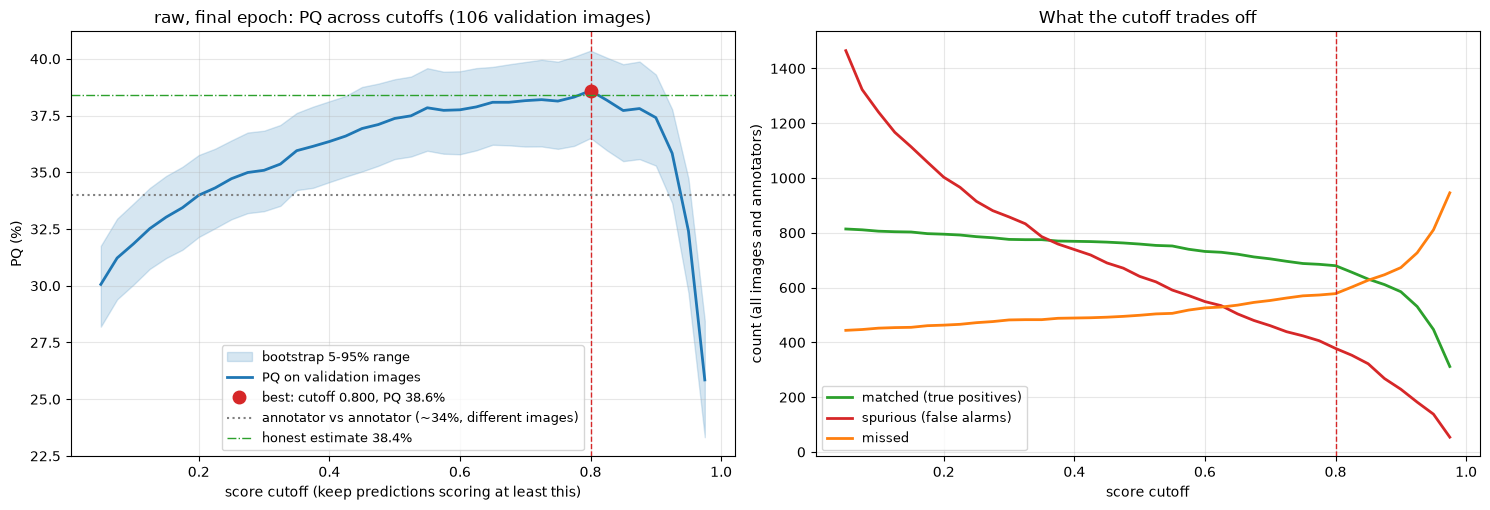

In [6]:
import time

import torch
from metrics import get_pq_score

# ---- settings ----
OPT_MODEL = "V1 raw, final epoch"                                   # any name from MODELS in section 1
OPT_CUTOFFS = [round(c, 3) for c in np.arange(0.05, 1.0, 0.025)]  # cutoffs to try
OPT_MAX_IMAGES = None                                            # None = all validation images; a number = only the first N
OPT_LOG_EVERY = 1                                                # print a line every N images
OPT_BOOTSTRAP = 300                                              # resamples for the shaded band
OPT_SPLIT_REPEATS = 300                                          # random half/half splits for the honest estimate
OPT_SEED = 0
HUMAN_AGREEMENT = 0.34                                           # annotator vs annotator, measured earlier (training images)
# ------------------

as_rle = lambda rs: [{"size": [2048, 2048], "counts": r.encode("ascii")} for r in rs]
source = list(SOURCES)[0]
cutoffs = np.array(OPT_CUTOFFS)
files = VAL_FILES[:OPT_MAX_IMAGES]
n_img, n_cut = len(files), len(cutoffs)

# stats[i, c] = (sum of IoU of matches, matched, spurious, missed) for image i at cutoff c, pooled over its annotators
stats = np.zeros((n_img, n_cut, 4))
kept_matrices = []          # (IoU matrix, prediction scores) per annotator version, for the cross-check
pq_of = lambda s: np.divide(s.sum(0)[:, 0], (s.sum(0)[:, 1] + 0.5 * s.sum(0)[:, 2] + 0.5 * s.sum(0)[:, 3]),
                            out=np.zeros(s.shape[1]), where=(s.sum(0)[:, 1] + 0.5 * s.sum(0)[:, 2] + 0.5 * s.sum(0)[:, 3]) > 0)

print(f"Optimising the score cutoff for '{OPT_MODEL}' on {n_img} validation images, {n_cut} cutoffs "
      f"({cutoffs[0]} to {cutoffs[-1]}).", flush=True)
t_start = time.time()
for n, f in enumerate(files):
    t_img = time.time()
    inst = get_instances(OPT_MODEL, source, f)             # every prediction with score >= 0.05, highest score first
    scores = np.array([s for s, _ in inst])
    rles = [r for _, r in inst]
    ids, gt = gt_for(f)
    for i in ids:
        n_gt = len(gt[i])
        M = (mask_util.iou(as_rle(rles), as_rle(gt[i]), [0] * n_gt).T if rles and n_gt else np.zeros((n_gt, len(rles))))
        kept_matrices.append((n, M, scores))
        for c, cut in enumerate(cutoffs):
            k = int((scores >= cut).sum())                 # predictions kept at this cutoff
            if k == 0:
                stats[n, c] += (0, 0, 0, n_gt)
                continue
            hit = M[:, :k] > 0.5                           # the official matching rule
            stats[n, c] += (M[:, :k][hit].sum(), hit.sum(), (hit.sum(0) == 0).sum(), (hit.sum(1) == 0).sum())
    if (n + 1) % OPT_LOG_EVERY == 0 or n + 1 == n_img:
        elapsed = time.time() - t_start
        eta = elapsed / (n + 1) * (n_img - n - 1)
        running = pq_of(stats[:n + 1])
        print(f"[{n + 1:>3}/{n_img}] {f}  {len(inst):>3} predictions, {len(ids)} annotator(s)  "
              f"({time.time() - t_img:.1f}s, ETA {eta / 60:.1f} min)  "
              f"running best: cutoff {cutoffs[running.argmax()]:.3f} -> PQ {100 * running.max():.1f}%", flush=True)

pq = pq_of(stats)
tot = stats.sum(0)
best = int(pq.argmax())
print(f"\nDone in {(time.time() - t_start) / 60:.1f} min. Results per cutoff (pooled over all images and annotators):")
print(f"{'cutoff':>7} {'PQ':>7} {'matched':>8} {'spurious':>9} {'missed':>7} {'mean IoU':>9}")
for c in range(n_cut):
    mark = "   <-- best" if c == best else ""
    print(f"{cutoffs[c]:>7.3f} {100 * pq[c]:>6.1f}% {int(tot[c, 1]):>8} {int(tot[c, 2]):>9} {int(tot[c, 3]):>7} "
          f"{tot[c, 0] / max(tot[c, 1], 1):>9.2f}{mark}")

# cross-check the fast calculation against the official scoring function at the best cutoff
official_rows = []
for n, M, scores in kept_matrices:
    k = int((scores >= cutoffs[best]).sum())
    official_rows.append({"iou_matrix": torch.tensor(M[:, :k], dtype=torch.float32), "n_gt": M.shape[0], "n_pred": k})
official = get_pq_score(pd.DataFrame(official_rows))
print(f"\nCross-check at cutoff {cutoffs[best]}: fast {100 * pq[best]:.2f}%  vs  official code {100 * official:.2f}%  "
      f"-> {'MATCH' if abs(pq[best] - official) < 1e-4 else 'MISMATCH, do not trust these numbers'}")

# how sure are we? bootstrap over images, and a tune-on-half / score-on-other-half estimate
rng = np.random.default_rng(OPT_SEED)
boot = np.array([pq_of(stats[rng.integers(0, n_img, n_img)]) for _ in range(OPT_BOOTSTRAP)])
lo, hi = np.percentile(boot, [5, 95], axis=0)
held_out = []
for _ in range(OPT_SPLIT_REPEATS):
    perm = rng.permutation(n_img)
    a, b = perm[: n_img // 2], perm[n_img // 2:]
    held_out.append(pq_of(stats[b])[pq_of(stats[a]).argmax()])
near_best = cutoffs[pq >= pq.max() - 0.01]
print(f"\nBest cutoff: {cutoffs[best]:.3f}  ->  PQ {100 * pq[best]:.1f}%  (bootstrap 5-95% range at that cutoff: "
      f"{100 * lo[best]:.1f}% to {100 * hi[best]:.1f}%)")
print(f"Cutoffs within 1 point of the best: {near_best.min():.3f} to {near_best.max():.3f}")
print(f"Honest estimate (cutoff tuned on one half of the images, scored on the other half, {OPT_SPLIT_REPEATS} splits): "
      f"{100 * np.mean(held_out):.1f}% +/- {100 * np.std(held_out):.1f}%")

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 5.2))
ax1.fill_between(cutoffs, 100 * lo, 100 * hi, color="tab:blue", alpha=0.18, label="bootstrap 5-95% range")
ax1.plot(cutoffs, 100 * pq, color="tab:blue", lw=2, label="PQ on validation images")
ax1.axvline(cutoffs[best], color="tab:red", ls="--", lw=1)
ax1.plot(cutoffs[best], 100 * pq[best], "o", color="tab:red", ms=9, label=f"best: cutoff {cutoffs[best]:.3f}, PQ {100 * pq[best]:.1f}%")
ax1.axhline(100 * HUMAN_AGREEMENT, color="gray", ls=":", label="annotator vs annotator (~34%, different images)")
ax1.axhline(100 * np.mean(held_out), color="tab:green", ls="-.", lw=1, label=f"honest estimate {100 * np.mean(held_out):.1f}%")
ax1.set_xlabel("score cutoff (keep predictions scoring at least this)")
ax1.set_ylabel("PQ (%)")
ax1.set_title(f"{OPT_MODEL}: PQ across cutoffs ({n_img} validation images)")
ax1.grid(alpha=0.3)
ax1.legend(loc="lower center", fontsize=9)

ax2.plot(cutoffs, tot[:, 1], color="tab:green", lw=2, label="matched (true positives)")
ax2.plot(cutoffs, tot[:, 2], color="tab:red", lw=2, label="spurious (false alarms)")
ax2.plot(cutoffs, tot[:, 3], color="tab:orange", lw=2, label="missed")
ax2.axvline(cutoffs[best], color="tab:red", ls="--", lw=1)
ax2.set_xlabel("score cutoff")
ax2.set_ylabel("count (all images and annotators)")
ax2.set_title("What the cutoff trades off")
ax2.grid(alpha=0.3)
ax2.legend(fontsize=9)
plt.tight_layout()
plt.show()

## Ideas

- Compare `V1 raw, final epoch` against `V1 raw, lowest val loss` on the same image: the earlier checkpoint finds fewer filaments.
- Lower the cutoff to 0.3 and watch the extra (mostly red) filaments appear. That is the trade-off behind the best cutoff of 0.8.
- Use the worst images from section 5 to see what kinds of filaments the model struggles with (small, faint, fragmented).
- On test images, check whether long filaments come out as one piece or several.